In [3]:
from __future__ import annotations

import time
from pathlib import Path
from urllib.parse import urlparse

import boto3
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.fs as pafs

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")


In [18]:
# -----------------------------------------------------------------------------
# Notebook configuration
# -----------------------------------------------------------------------------
# Update DATA_URI if needed.
#
# Example S3:
# DATA_URI = "s3://pdga-bronze-266672886271-us-east-2/gold/pdga/wind_effects/model_inputs_hole/"
#
# Example local:
# DATA_URI = r"C:\path\to\gold\pdga\wind_effects\model_inputs_hole"
# -----------------------------------------------------------------------------

DATA_URI = "s3://pdga-bronze-266672886271-us-east-2/gold/pdga/wind_effects/model_inputs_hole/"
AWS_REGION = "us-east-2"

# We train one CatBoost model on one held-out-by-event split.
SPLIT_SEED = 11
TEST_SIZE = 0.20

KEEP_ONLY_WEATHER_READY_ROWS = True
USE_DIVISION = True

# Export location for scored residuals and summary tables.
OUTPUT_DIR = Path.cwd() / "notebook_exports"
OUTPUT_DIR.mkdir(exist_ok=True)

# CatBoost params:
# - one split only
# - modest complexity for notebook stability
CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1200,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": 42,
    "verbose": 100,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}

In [5]:
# -----------------------------------------------------------------------------
# S3 / parquet loading helpers
# -----------------------------------------------------------------------------
# We use an explicit schema to avoid Arrow merge errors across partitions
# such as int32 vs int64 for event_year or similar columns.
# -----------------------------------------------------------------------------

def get_s3_bucket_region(bucket: str, default_region: str = "us-east-1") -> str:
    s3 = boto3.client("s3", region_name=default_region)
    resp = s3.get_bucket_location(Bucket=bucket)
    region = resp.get("LocationConstraint")
    if region is None:
        return "us-east-1"
    return region


def build_hole_input_schema() -> pa.Schema:
    return pa.schema(
        [
            pa.field("event_year", pa.int64()),
            pa.field("tourn_id", pa.int64()),
            pa.field("round_number", pa.int64()),
            pa.field("hole_number", pa.int64()),
            pa.field("player_key", pa.string()),
            pa.field("player_rating", pa.int64()),
            pa.field("course_id", pa.int64()),
            pa.field("hole_length", pa.float64()),
            pa.field("hole_par", pa.int64()),
            pa.field("hole_score", pa.int64()),
            pa.field("actual_strokes", pa.int64()),
            pa.field("hole_to_par", pa.int64()),
            pa.field("strokes_over_par", pa.int64()),
            pa.field("target_strokes_over_par", pa.int64()),
            pa.field("division", pa.string()),
            pa.field("weather_available_flag", pa.bool_()),
            pa.field("wx_weather_missing_flag", pa.bool_()),
            pa.field("wx_wind_speed_mps", pa.float64()),
            pa.field("wx_wind_gust_mps", pa.float64()),
            pa.field("wx_wind_dir_deg", pa.float64()),
            pa.field("wx_temperature_c", pa.float64()),
            pa.field("wx_precip_mm", pa.float64()),
            pa.field("wx_pressure_hpa", pa.float64()),
            pa.field("wx_relative_humidity_pct", pa.float64()),
            pa.field("feature_wind_speed_mps", pa.float64()),
            pa.field("feature_wind_gust_mps", pa.float64()),
            pa.field("feature_wind_dir_deg", pa.float64()),
            pa.field("feature_temp_c", pa.float64()),
            pa.field("feature_precip_mm", pa.float64()),
            pa.field("feature_pressure_hpa", pa.float64()),
            pa.field("feature_humidity_pct", pa.float64()),
            pa.field("wind_speed_bucket", pa.string()),
            pa.field("layout_id", pa.int64()),
            pa.field("feature_layout_id", pa.int64()),
            pa.field("feature_course_id", pa.int64()),
            pa.field("source_content_sha256", pa.string()),
            pa.field("row_hash_sha256", pa.string()),
        ]
    )


def _build_arrow_dataset(uri: str, aws_region: str = "us-east-1") -> ds.Dataset:
    schema = build_hole_input_schema()

    if uri.startswith("s3://"):
        parsed = urlparse(uri)
        bucket = parsed.netloc
        key = parsed.path.lstrip("/").rstrip("/")
        bucket_region = get_s3_bucket_region(bucket, default_region=aws_region)
        fs = pafs.S3FileSystem(region=bucket_region)

        return ds.dataset(
            f"{bucket}/{key}",
            filesystem=fs,
            format="parquet",
            partitioning="hive",
            schema=schema,
        )

    path = Path(uri)
    if not path.exists():
        raise FileNotFoundError(f"Could not find dataset path: {uri}")

    return ds.dataset(
        str(path),
        format="parquet",
        partitioning="hive",
        schema=schema,
    )


def load_partitioned_parquet(uri: str, aws_region: str = "us-east-1") -> pd.DataFrame:
    dataset = _build_arrow_dataset(uri=uri, aws_region=aws_region)
    table = dataset.to_table()
    return table.to_pandas()

In [6]:
# -----------------------------------------------------------------------------
# Canonicalization helpers
# -----------------------------------------------------------------------------
# The modeling dataset may expose the same concept under multiple column names.
# We standardize everything into one clean hole-level frame.
# -----------------------------------------------------------------------------

def first_present(df: pd.DataFrame, candidates: list[str], required: bool = False) -> pd.Series:
    for col in candidates:
        if col in df.columns:
            return df[col]
    if required:
        raise KeyError(f"Missing required column. Tried: {candidates}")
    return pd.Series(pd.NA, index=df.index)


def canonicalize_hole_model_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=raw_df.index)

    # Core identifiers
    out["event_year"] = first_present(raw_df, ["event_year"])
    out["tourn_id"] = first_present(raw_df, ["tourn_id", "event_id"], required=True)
    out["round_number"] = first_present(raw_df, ["round_number"], required=True)
    out["hole_number"] = first_present(raw_df, ["hole_number"], required=True)
    out["player_key"] = first_present(raw_df, ["player_key"], required=True)

    # Target and core model inputs
    out["actual_strokes"] = first_present(raw_df, ["actual_strokes", "hole_score"], required=True)
    out["target_strokes_over_par"] = first_present(
        raw_df,
        ["target_strokes_over_par", "strokes_over_par", "hole_to_par"],
        required=False,
    )
    out["player_rating"] = first_present(raw_df, ["player_rating"], required=True)
    out["course_id"] = first_present(raw_df, ["course_id", "feature_course_id"], required=True)
    out["hole_length"] = first_present(raw_df, ["hole_length"], required=True)
    out["hole_par"] = first_present(raw_df, ["hole_par", "feature_hole_par"], required=True)
    out["division"] = first_present(raw_df, ["division"], required=False)

    # Weather / wind fields for downstream wind-impact analysis
    out["weather_available_flag"] = first_present(raw_df, ["weather_available_flag"], required=False)
    out["wind_speed_bucket"] = first_present(raw_df, ["wind_speed_bucket"], required=False)

    out["wind_speed_mps"] = first_present(raw_df, ["wx_wind_speed_mps", "feature_wind_speed_mps"], required=False)
    out["wind_gust_mps"] = first_present(raw_df, ["wx_wind_gust_mps", "feature_wind_gust_mps"], required=False)
    out["wind_dir_deg"] = first_present(raw_df, ["wx_wind_dir_deg", "feature_wind_dir_deg"], required=False)
    out["temp_c"] = first_present(raw_df, ["wx_temperature_c", "feature_temp_c"], required=False)
    out["precip_mm"] = first_present(raw_df, ["wx_precip_mm", "feature_precip_mm"], required=False)
    out["pressure_hpa"] = first_present(raw_df, ["wx_pressure_hpa", "feature_pressure_hpa"], required=False)
    out["humidity_pct"] = first_present(raw_df, ["wx_relative_humidity_pct", "feature_humidity_pct"], required=False)

    numeric_cols = [
        "event_year",
        "tourn_id",
        "round_number",
        "hole_number",
        "actual_strokes",
        "target_strokes_over_par",
        "player_rating",
        "course_id",
        "hole_length",
        "hole_par",
        "wind_speed_mps",
        "wind_gust_mps",
        "wind_dir_deg",
        "temp_c",
        "precip_mm",
        "pressure_hpa",
        "humidity_pct",
    ]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["player_key"] = out["player_key"].astype("string")
    out["division"] = out["division"].astype("string")
    out["wind_speed_bucket"] = out["wind_speed_bucket"].astype("string")
    out["weather_available_flag"] = out["weather_available_flag"].astype("boolean")

    return out


In [7]:
# -----------------------------------------------------------------------------
# Load and inspect the raw parquet dataset
# -----------------------------------------------------------------------------

raw_df = load_partitioned_parquet(DATA_URI, aws_region=AWS_REGION)
model_df = canonicalize_hole_model_frame(raw_df)

print("Raw shape:", raw_df.shape)
print("Canonical shape:", model_df.shape)
model_df.head()


Raw shape: (12093744, 37)
Canonical shape: (12093744, 21)


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct
0,2025,90000,1,1,PDGA#112424,3,0,935.0,25925.0,274.0,3,MA50,True,light,4.48,8.6,329.0,-3.0,0.0,1018.8,69.0
1,2025,90000,1,1,PDGA#113208,5,2,NaN,25925.0,274.0,3,MA2,True,light,4.48,8.6,329.0,-3.0,0.0,1018.8,69.0
2,2025,90000,1,1,PDGA#119010,3,0,951.0,25925.0,274.0,3,MPO,True,light,4.74,8.7,332.0,-3.7,0.0,1021.1,73.0
3,2025,90000,1,1,PDGA#138418,3,0,922.0,25925.0,274.0,3,MA1,True,light,4.74,8.7,332.0,-3.7,0.0,1021.1,73.0
4,2025,90000,1,1,PDGA#176385,4,1,875.0,25925.0,274.0,3,MA3,True,light,4.42,8.2,322.0,-3.4,0.0,1020.3,69.0


In [8]:
# -----------------------------------------------------------------------------
# Data quality filtering
# -----------------------------------------------------------------------------
# We keep only rows that look valid for expected-strokes modeling.
# -----------------------------------------------------------------------------

required_model_cols = [
    "event_year",
    "tourn_id",
    "round_number",
    "hole_number",
    "player_key",
    "actual_strokes",
    "player_rating",
    "course_id",
    "hole_length",
    "hole_par",
]

before_rows = len(model_df)

if KEEP_ONLY_WEATHER_READY_ROWS and model_df["weather_available_flag"].notna().any():
    model_df = model_df[model_df["weather_available_flag"] == True].copy()

model_df = model_df.dropna(subset=required_model_cols).copy()

model_df = model_df[model_df["actual_strokes"].between(1, 15)].copy()
model_df = model_df[model_df["hole_par"].between(2, 6)].copy()
model_df = model_df[model_df["hole_length"].between(30, 2000)].copy()
model_df = model_df[model_df["player_rating"].between(500, 1100)].copy()

model_df["course_id"] = model_df["course_id"].astype("Int64").astype("string")
model_df["hole_par"] = model_df["hole_par"].astype("Int64").astype("string")
model_df["division"] = model_df["division"].astype("string")

after_rows = len(model_df)

print(f"Rows before filtering: {before_rows:,}")
print(f"Rows after filtering:  {after_rows:,}")
print(f"Unique events:         {model_df['tourn_id'].nunique():,}")
print(f"Unique courses:        {model_df['course_id'].nunique():,}")
model_df.head()


Rows before filtering: 12,093,744
Rows after filtering:  7,747,821
Unique events:         6,115
Unique courses:        3,020


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct
0,2025,90000,1,1,PDGA#112424,3,0,935.0,25925,274.0,3,MA50,True,light,4.48,8.6,329.0,-3.0,0.0,1018.8,69.0
2,2025,90000,1,1,PDGA#119010,3,0,951.0,25925,274.0,3,MPO,True,light,4.74,8.7,332.0,-3.7,0.0,1021.1,73.0
3,2025,90000,1,1,PDGA#138418,3,0,922.0,25925,274.0,3,MA1,True,light,4.74,8.7,332.0,-3.7,0.0,1021.1,73.0
4,2025,90000,1,1,PDGA#176385,4,1,875.0,25925,274.0,3,MA3,True,light,4.42,8.2,322.0,-3.4,0.0,1020.3,69.0
7,2025,90000,1,1,PDGA#208208,5,2,771.0,25925,274.0,3,MJ15,True,light,4.42,8.2,322.0,-3.4,0.0,1020.3,69.0


In [9]:
# -----------------------------------------------------------------------------
# Train / test split helper
# -----------------------------------------------------------------------------
# We hold out entire tournaments so the model is evaluated on unseen events.
# -----------------------------------------------------------------------------

def event_split(df: pd.DataFrame, seed: int, test_size: float = 0.20) -> tuple[pd.DataFrame, pd.DataFrame]:
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    groups = df["tourn_id"].astype(int)
    train_idx, test_idx = next(splitter.split(df, groups=groups))

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_events = set(train_df["tourn_id"].astype(int).unique())
    test_events = set(test_df["tourn_id"].astype(int).unique())
    assert train_events.isdisjoint(test_events), "Train/test event leakage detected"

    return train_df, test_df


train_df, test_df = event_split(model_df, seed=SPLIT_SEED, test_size=TEST_SIZE)

print("Train rows:", len(train_df))
print("Test rows: ", len(test_df))
print("Train events:", train_df["tourn_id"].nunique())
print("Test events: ", test_df["tourn_id"].nunique())

Train rows: 6183077
Test rows:  1564744
Train events: 4892
Test events:  1223


In [20]:
# -----------------------------------------------------------------------------
# CatBoost training
# -----------------------------------------------------------------------------
# We use:
# - numeric features: player_rating, hole_length
# - categorical features: hole_par, course_id, optional division
# -----------------------------------------------------------------------------

feature_cols = ["player_rating", "hole_length", "hole_par", "course_id"]
categorical_cols = ["hole_par", "course_id"]

if USE_DIVISION and train_df["division"].notna().any():
    feature_cols.append("division")
    categorical_cols.append("division")

fit_train = train_df.copy()
fit_test = test_df.copy()

for col in categorical_cols:
    fit_train[col] = fit_train[col].astype("string").fillna("__MISSING__").astype(str)
    fit_test[col] = fit_test[col].astype("string").fillna("__MISSING__").astype(str)

    # Map unseen test categories to a sentinel value.
    train_levels = set(fit_train[col].unique())
    fit_test[col] = fit_test[col].where(fit_test[col].isin(train_levels), "__MISSING__")

for col in ["player_rating", "hole_length", "actual_strokes"]:
    fit_train[col] = pd.to_numeric(fit_train[col], errors="coerce")
    fit_test[col] = pd.to_numeric(fit_test[col], errors="coerce")

fit_train = fit_train.dropna(subset=["player_rating", "hole_length", "actual_strokes"]).copy()
fit_test = fit_test.dropna(subset=["player_rating", "hole_length", "actual_strokes"]).copy()

cat_idx = [feature_cols.index(c) for c in categorical_cols]

train_pool = Pool(
    data=fit_train[feature_cols],
    label=fit_train["actual_strokes"],
    cat_features=cat_idx,
)

test_pool = Pool(
    data=fit_test[feature_cols],
    label=fit_test["actual_strokes"],
    cat_features=cat_idx,
)

start = time.perf_counter()

catboost_model = CatBoostRegressor(**CATBOOST_PARAMS)
catboost_model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    early_stopping_rounds=100,
)

test_pred = catboost_model.predict(test_pool)

train_seconds = time.perf_counter() - start
print(f"Training runtime (sec): {train_seconds:,.2f}")


0:	learn: 1.0153851	test: 1.0156905	best: 1.0156905 (0)	total: 1.84s	remaining: 36m 41s
100:	learn: 0.7938949	test: 0.7997817	best: 0.7997817 (100)	total: 2m 11s	remaining: 23m 49s
200:	learn: 0.7903551	test: 0.7965598	best: 0.7965598 (200)	total: 4m 36s	remaining: 22m 55s
300:	learn: 0.7891387	test: 0.7956443	best: 0.7956443 (300)	total: 6m 56s	remaining: 20m 44s
400:	learn: 0.7885318	test: 0.7953756	best: 0.7953756 (400)	total: 9m 3s	remaining: 18m 1s
500:	learn: 0.7881498	test: 0.7953029	best: 0.7953027 (497)	total: 11m 10s	remaining: 15m 35s
600:	learn: 0.7878696	test: 0.7950747	best: 0.7950747 (600)	total: 13m 16s	remaining: 13m 13s
700:	learn: 0.7876350	test: 0.7950137	best: 0.7949583 (681)	total: 15m 18s	remaining: 10m 53s
800:	learn: 0.7874334	test: 0.7947997	best: 0.7947997 (800)	total: 17m 20s	remaining: 8m 38s
900:	learn: 0.7872624	test: 0.7946927	best: 0.7946927 (900)	total: 19m 24s	remaining: 6m 26s
1000:	learn: 0.7871158	test: 0.7946684	best: 0.7946681 (963)	total: 21m 26

In [21]:
# -----------------------------------------------------------------------------
# Overall held-out metrics
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


overall_metrics = regression_metrics(fit_test["actual_strokes"], test_pred)
overall_metrics_df = pd.DataFrame([overall_metrics])

overall_metrics_df

,mae,rmse,r2
0,0.589087,0.794582,0.409653


In [22]:
# -----------------------------------------------------------------------------
# Build the detailed scored residual dataframe
# -----------------------------------------------------------------------------
# This is the main export from Notebook 1. Notebook 2 will load this file.
# -----------------------------------------------------------------------------

residuals_df = fit_test[
    [
        "event_year",
        "tourn_id",
        "round_number",
        "hole_number",
        "player_key",
        "actual_strokes",
        "target_strokes_over_par",
        "player_rating",
        "course_id",
        "hole_length",
        "hole_par",
        "division",
        "weather_available_flag",
        "wind_speed_bucket",
        "wind_speed_mps",
        "wind_gust_mps",
        "wind_dir_deg",
        "temp_c",
        "precip_mm",
        "pressure_hpa",
        "humidity_pct",
    ]
].copy()

residuals_df["expected_strokes"] = test_pred
residuals_df["residual_strokes"] = residuals_df["actual_strokes"] - residuals_df["expected_strokes"]
residuals_df["abs_residual_strokes"] = residuals_df["residual_strokes"].abs()
residuals_df["model_name"] = "catboost"
residuals_df["model_version"] = "prototype_v1"
residuals_df["split_seed"] = SPLIT_SEED

residuals_df.head()


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,wind_speed_bucket,wind_speed_mps,wind_gust_mps,wind_dir_deg,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed
324,2025,90001,1,1,PDGA#108871,4,0,911.0,241646,515.0,4,FPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.296190,-0.296190,0.296190,catboost,prototype_v1,11
325,2025,90001,1,1,PDGA#121690,3,-1,997.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.684867,-0.684867,0.684867,catboost,prototype_v1,11
326,2025,90001,1,1,PDGA#126698,4,0,930.0,241646,515.0,4,MA40,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.129436,-0.129436,0.129436,catboost,prototype_v1,11
327,2025,90001,1,1,PDGA#127239,4,0,922.0,241646,515.0,4,MA2,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,4.132211,-0.132211,0.132211,catboost,prototype_v1,11
328,2025,90001,1,1,PDGA#132233,5,1,955.0,241646,515.0,4,MPO,True,calm,1.66,4.0,265.0,14.4,0.0,1020.4,76.0,3.982817,1.017183,1.017183,catboost,prototype_v1,11


In [23]:
# -----------------------------------------------------------------------------
# Event-level summary
# -----------------------------------------------------------------------------

event_metrics_rows = []

for tourn_id, g in residuals_df.groupby("tourn_id", dropna=False):
    event_metrics_rows.append(
        {
            "tourn_id": tourn_id,
            "rows": len(g),
            "actual_mean": g["actual_strokes"].mean(),
            "expected_mean": g["expected_strokes"].mean(),
            "residual_mean": g["residual_strokes"].mean(),
            "residual_median": g["residual_strokes"].median(),
            "residual_std": g["residual_strokes"].std(),
            "mae": mean_absolute_error(g["actual_strokes"], g["expected_strokes"]),
            "rmse": float(np.sqrt(mean_squared_error(g["actual_strokes"], g["expected_strokes"]))),
            "r2": r2_score(g["actual_strokes"], g["expected_strokes"]) if len(g) > 1 else np.nan,
        }
    )

event_metrics_df = pd.DataFrame(event_metrics_rows).sort_values(["rmse", "mae"], ascending=[False, False]).reset_index(drop=True)
event_metrics_df.head(20)


,tourn_id,rows,actual_mean,expected_mean,residual_mean,residual_median,residual_std,mae,rmse,r2
0,92986,1998,4.478979,3.882382,0.596597,0.359158,1.212584,0.946840,1.351130,0.394173
1,90918,108,2.907407,3.829765,-0.922358,-1.118981,0.944704,1.018996,1.317173,-3.157027
2,99324,1281,4.608119,3.972142,0.635977,0.472638,1.088356,0.920665,1.260182,0.146425
3,97130,963,3.992731,3.503611,0.489120,0.210814,1.161521,0.861235,1.259749,0.119138
4,91196,234,3.854701,3.619504,0.235197,0.007891,1.235401,0.887471,1.254995,0.306005
5,94025,126,4.634921,4.342464,0.292457,0.055344,1.158237,0.834627,1.190125,0.511328
6,96898,666,4.421922,3.993544,0.428378,0.245882,1.110138,0.858118,1.189144,0.363000
7,92696,2520,4.552381,4.114114,0.438267,0.224723,1.098607,0.826315,1.182597,0.396841
8,91981,918,3.989107,3.956265,0.032842,0.013385,1.163011,0.908621,1.162842,0.056670
9,93049,234,4.008547,3.796294,0.212253,-0.008152,1.129574,0.847542,1.146968,0.333665


In [24]:
# -----------------------------------------------------------------------------
# Residual summaries by model inputs
# -----------------------------------------------------------------------------

def summarize_residuals_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return (
        df.groupby(group_col, dropna=False, as_index=False)
        .agg(
            rows=("actual_strokes", "size"),
            actual_mean=("actual_strokes", "mean"),
            expected_mean=("expected_strokes", "mean"),
            residual_mean=("residual_strokes", "mean"),
            residual_median=("residual_strokes", "median"),
            residual_std=("residual_strokes", "std"),
            mae=("abs_residual_strokes", "mean"),
        )
        .sort_values(["rows", "residual_mean"], ascending=[False, False])
        .reset_index(drop=True)
    )


residuals_by_tourn_id = summarize_residuals_by_group(residuals_df, "tourn_id")
residuals_by_course_id = summarize_residuals_by_group(residuals_df, "course_id")
residuals_by_division = summarize_residuals_by_group(residuals_df[residuals_df["division"].notna()].copy(), "division")
residuals_by_hole_par = summarize_residuals_by_group(residuals_df, "hole_par")

residuals_df["hole_length_bin"] = pd.qcut(residuals_df["hole_length"], q=10, duplicates="drop")
residuals_df["player_rating_bin"] = pd.qcut(residuals_df["player_rating"], q=10, duplicates="drop")

residuals_by_hole_length_bin = summarize_residuals_by_group(residuals_df, "hole_length_bin")
residuals_by_player_rating_bin = summarize_residuals_by_group(residuals_df, "player_rating_bin")

residuals_by_hole_par


,hole_par,rows,actual_mean,expected_mean,residual_mean,residual_median,residual_std,mae
0,3,1225265,3.103798,3.103899,-0.000101,-0.047896,0.745075,0.552704
1,4,301032,4.240748,4.214852,0.025896,-0.075182,0.923183,0.701224
2,5,38333,5.443039,5.367636,0.075402,-0.068078,1.148551,0.870033
3,6,114,5.964912,6.554891,-0.589979,-0.683708,1.129985,1.050575


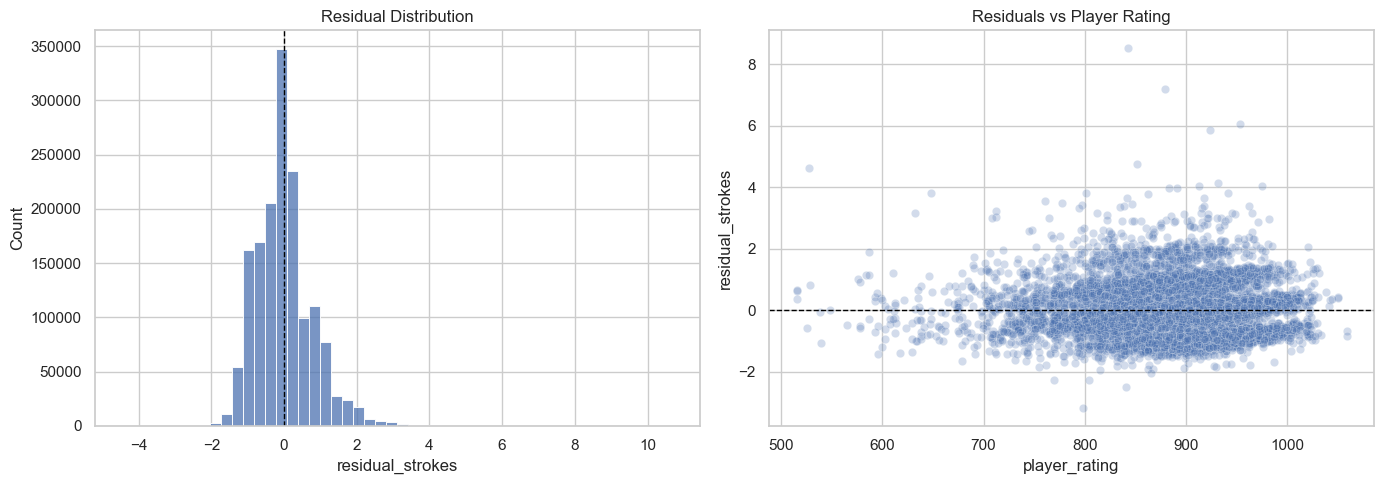

In [25]:
# Quick diagnostic charts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals_df["residual_strokes"], bins=50, ax=axes[0])
axes[0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residual Distribution")

sns.scatterplot(
    data=residuals_df.sample(min(10000, len(residuals_df)), random_state=42),
    x="player_rating",
    y="residual_strokes",
    alpha=0.25,
    ax=axes[1],
)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Player Rating")

plt.tight_layout()
plt.show()

In [26]:
# -----------------------------------------------------------------------------
# Export artifacts
# -----------------------------------------------------------------------------
# Drop interval-bin analysis columns before parquet export because pyarrow
# does not reliably serialize pandas Interval categorical types.
# -----------------------------------------------------------------------------

residual_path = OUTPUT_DIR / "catboost_expected_strokes_residuals_v1.parquet"

residuals_export_df = residuals_df.drop(
    columns=["hole_length_bin", "player_rating_bin"],
    errors="ignore",
).copy()

residuals_export_df.to_parquet(residual_path, index=False)
overall_metrics_df.to_csv(OUTPUT_DIR / "catboost_expected_strokes_overall_metrics_v1.csv", index=False)
event_metrics_df.to_csv(OUTPUT_DIR / "catboost_expected_strokes_event_metrics_v1.csv", index=False)
residuals_by_tourn_id.to_csv(OUTPUT_DIR / "catboost_expected_strokes_residuals_by_tourn_id_v1.csv", index=False)
residuals_by_course_id.to_csv(OUTPUT_DIR / "catboost_expected_strokes_residuals_by_course_id_v1.csv", index=False)
residuals_by_division.to_csv(OUTPUT_DIR / "catboost_expected_strokes_residuals_by_division_v1.csv", index=False)
residuals_by_hole_par.to_csv(OUTPUT_DIR / "catboost_expected_strokes_residuals_by_hole_par_v1.csv", index=False)
residuals_by_hole_length_bin.to_csv(OUTPUT_DIR / "catboost_expected_strokes_residuals_by_hole_length_bin_v1.csv", index=False)
residuals_by_player_rating_bin.to_csv(OUTPUT_DIR / "catboost_expected_strokes_residuals_by_player_rating_bin_v1.csv", index=False)

print("Wrote artifacts to:", OUTPUT_DIR)
print("Detailed residual parquet:", residual_path)

Wrote artifacts to: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports
Detailed residual parquet: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\catboost_expected_strokes_residuals_v1.parquet
